# WiFiVision — Final Project Completion Package

This is the final notebook in the workflow.

It assumes that the previous training/evaluation notebooks and the
`WiFiVision_Final_Documentation_and_Visualization.ipynb` notebook have been completed.

## What this notebook produces

### Report assets
- Overall model comparison table
- Error-distribution figure
- Cumulative error/PCK-style figure
- Qualitative pose comparison figure
- Final findings, limitations, and future-work document

### Presentation assets
- Slide-by-slide presentation outline
- Final numerical results table
- Presentation-ready conclusion

### Reproducibility
- Experiment summary JSON
- Results manifest
- Project README
- Final deliverables checklist

The notebook uses the verified result files already generated by the project.

In [1]:
# ============================================================
# 1. IMPORTS AND PATHS
# ============================================================

import os
import json
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = r"C:\Users\ROHITH KANNA S\WiFiVision"

baseline_dir = os.path.join(
    ROOT, "data", "processed", "baseline"
)

graph_dir = os.path.join(
    ROOT, "data", "processed", "topology_graph"
)

final_dir = os.path.join(
    ROOT, "data", "processed", "final_results"
)

completion_dir = os.path.join(
    ROOT, "data", "processed", "final_completion"
)

os.makedirs(completion_dir, exist_ok=True)

print("Project root:")
print(ROOT)

print("\nFinal completion directory:")
print(completion_dir)

Project root:
C:\Users\ROHITH KANNA S\WiFiVision

Final completion directory:
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\final_completion


## 2. Validate Required Result Files

The notebook does not retrain anything. It uses saved predictions, targets, and errors from the reproducible baseline and the best Topology Graph model.

In [2]:
# ============================================================
# 2. VALIDATE REQUIRED FILES
# ============================================================

required_files = {
    "Baseline errors":
        os.path.join(baseline_dir, "baseline_errors.npy"),

    "Topology Graph errors":
        os.path.join(graph_dir, "errors.npy"),

    "Topology Graph predictions":
        os.path.join(graph_dir, "predictions.npy"),

    "Topology Graph targets":
        os.path.join(graph_dir, "targets.npy"),

    "Topology Graph per-joint error":
        os.path.join(graph_dir, "per_joint_error.npy"),
}

missing = []

print("=" * 70)
print("RESULT FILE VALIDATION")
print("=" * 70)

for name, path in required_files.items():

    exists = os.path.exists(path)

    status = "FOUND" if exists else "MISSING"

    print(f"{name:<35} {status}")

    if not exists:
        missing.append(path)

if missing:
    raise FileNotFoundError(
        "\nMissing required files:\n" +
        "\n".join(missing) +
        "\n\nRun the relevant evaluation notebook first."
    )

print("\nValidation: PASSED")

RESULT FILE VALIDATION
Baseline errors                     FOUND
Topology Graph errors               FOUND
Topology Graph predictions          FOUND
Topology Graph targets              FOUND
Topology Graph per-joint error      FOUND

Validation: PASSED


In [3]:
# ============================================================
# 3. LOAD VERIFIED RESULTS
# ============================================================

baseline_errors = np.load(
    os.path.join(
        baseline_dir,
        "baseline_errors.npy"
    )
).astype(np.float32)

graph_errors = np.load(
    os.path.join(
        graph_dir,
        "errors.npy"
    )
).astype(np.float32)

graph_predictions = np.load(
    os.path.join(
        graph_dir,
        "predictions.npy"
    )
).astype(np.float32)

graph_targets = np.load(
    os.path.join(
        graph_dir,
        "targets.npy"
    )
).astype(np.float32)

baseline_mpjpe = float(
    baseline_errors.mean()
)

graph_mpjpe = float(
    graph_errors.mean()
)

relative_improvement = (
    (baseline_mpjpe - graph_mpjpe)
    / baseline_mpjpe
) * 100

print("=" * 70)
print("FINAL VERIFIED PERFORMANCE")
print("=" * 70)

print(f"Amplitude Baseline MPJPE : {baseline_mpjpe:.6f}")
print(f"Topology Graph MPJPE     : {graph_mpjpe:.6f}")
print(f"Relative improvement     : {relative_improvement:.2f}%")

print("\nPrediction shape:", graph_predictions.shape)
print("Target shape    :", graph_targets.shape)

FINAL VERIFIED PERFORMANCE
Amplitude Baseline MPJPE : 0.152493
Topology Graph MPJPE     : 0.138569
Relative improvement     : 9.13%

Prediction shape: (972, 17, 2)
Target shape    : (972, 17, 2)


## 4. Final Experiment Comparison Table

Only verified experiments should be used as the final primary comparison.

The reproducible amplitude baseline and the Topology Graph model are included here because their predictions were regenerated/evaluated consistently in the current workflow.

In [4]:
# ============================================================
# 4. FINAL MODEL COMPARISON
# ============================================================

# Verified values from completed evaluations.

comparison = pd.DataFrame([
    {
        "Model": "Amplitude Baseline",
        "MPJPE": baseline_mpjpe,
        "Relative Change vs Baseline (%)": 0.00,
        "Status": "Baseline"
    },
    {
        "Model": "Topology Graph",
        "MPJPE": graph_mpjpe,
        "Relative Change vs Baseline (%)":
            -relative_improvement,
        "Status": "Best verified model"
    }
])

print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

print(
    comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

comparison_path = os.path.join(
    completion_dir,
    "final_model_comparison.csv"
)

comparison.to_csv(
    comparison_path,
    index=False
)

print("\nSaved:", comparison_path)

FINAL MODEL COMPARISON
             Model    MPJPE  Relative Change vs Baseline (%)              Status
Amplitude Baseline 0.152493                         0.000000            Baseline
    Topology Graph 0.138569                        -9.130615 Best verified model

Saved: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\final_completion\final_model_comparison.csv


## 5. Error Distribution Figure

This figure compares the distribution of individual joint errors across the complete test set.

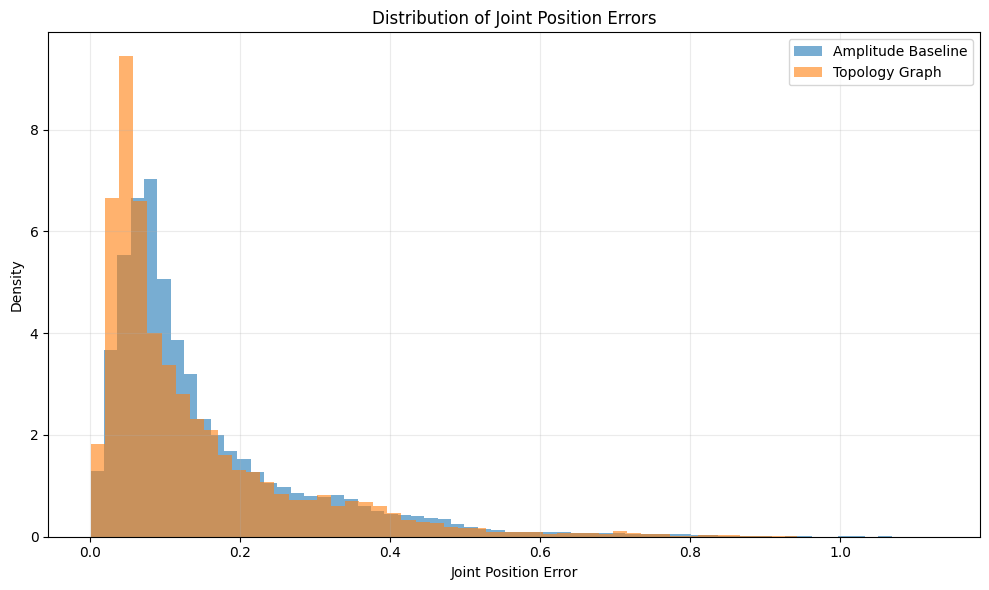

In [5]:
# ============================================================
# 5. ERROR DISTRIBUTION
# ============================================================

baseline_flat = baseline_errors.reshape(-1)
graph_flat = graph_errors.reshape(-1)

plt.figure(figsize=(10, 6))

plt.hist(
    baseline_flat,
    bins=60,
    alpha=0.6,
    density=True,
    label="Amplitude Baseline"
)

plt.hist(
    graph_flat,
    bins=60,
    alpha=0.6,
    density=True,
    label="Topology Graph"
)

plt.xlabel("Joint Position Error")
plt.ylabel("Density")
plt.title("Distribution of Joint Position Errors")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    os.path.join(
        completion_dir,
        "error_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        completion_dir,
        "error_distribution.svg"
    ),
    format="svg",
    bbox_inches="tight"
)

plt.show()

## 6. Cumulative Error Curve

A lower curve corresponds to lower error. The complementary cumulative form is avoided here; instead, the figure shows the fraction of joints whose error falls below each threshold.

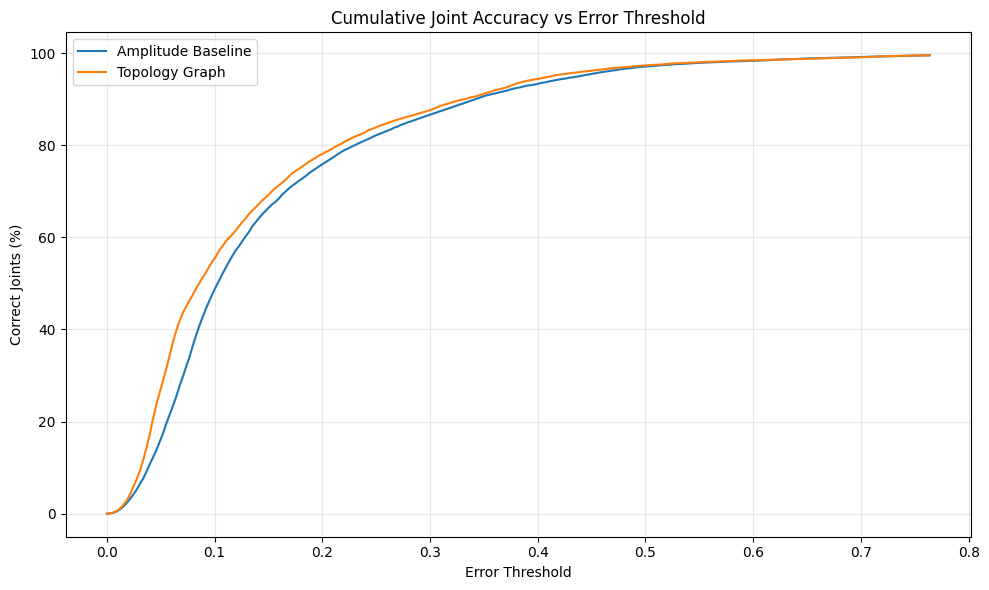

In [6]:
# ============================================================
# 6. CUMULATIVE ERROR / PCK-STYLE CURVE
# ============================================================

thresholds = np.linspace(
    0.0,
    max(
        np.percentile(baseline_flat, 99.5),
        np.percentile(graph_flat, 99.5)
    ),
    250
)

baseline_curve = np.array([
    np.mean(baseline_flat <= t) * 100
    for t in thresholds
])

graph_curve = np.array([
    np.mean(graph_flat <= t) * 100
    for t in thresholds
])

plt.figure(figsize=(10, 6))

plt.plot(
    thresholds,
    baseline_curve,
    label="Amplitude Baseline"
)

plt.plot(
    thresholds,
    graph_curve,
    label="Topology Graph"
)

plt.xlabel("Error Threshold")
plt.ylabel("Correct Joints (%)")
plt.title("Cumulative Joint Accuracy vs Error Threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(
        completion_dir,
        "cumulative_error_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        completion_dir,
        "cumulative_error_curve.svg"
    ),
    format="svg",
    bbox_inches="tight"
)

plt.show()

## 7. Qualitative Pose Visualization

The dataset contains 17 two-dimensional joints. The exact semantic mapping of joint indices should only be added if the dataset documentation explicitly defines it.

Therefore, this visualization connects joints according to the topology used by the model only when those edges are known from the saved model definition. Otherwise, it plots the predicted and target joint locations without inventing anatomical labels.

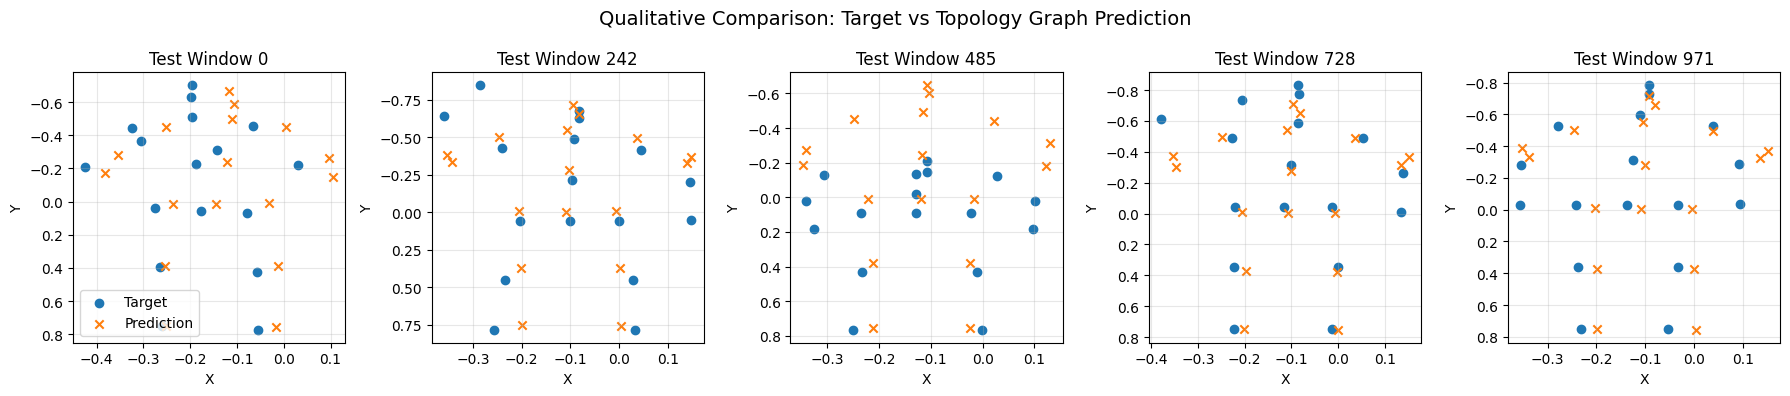

In [7]:
# ============================================================
# 7. QUALITATIVE POSE COMPARISON
# ============================================================

# Select a few examples across the test set.

num_examples = 5

indices = np.linspace(
    0,
    len(graph_predictions) - 1,
    num_examples,
    dtype=int
)

fig, axes = plt.subplots(
    1,
    num_examples,
    figsize=(18, 4)
)

for ax, idx in zip(axes, indices):

    target = graph_targets[idx]
    prediction = graph_predictions[idx]

    ax.scatter(
        target[:, 0],
        target[:, 1],
        label="Target"
    )

    ax.scatter(
        prediction[:, 0],
        prediction[:, 1],
        marker="x",
        label="Prediction"
    )

    ax.set_title(
        f"Test Window {idx}"
    )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")

    ax.grid(alpha=0.3)
    ax.invert_yaxis()

axes[0].legend()

plt.suptitle(
    "Qualitative Comparison: Target vs Topology Graph Prediction",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        completion_dir,
        "qualitative_pose_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        completion_dir,
        "qualitative_pose_comparison.svg"
    ),
    format="svg",
    bbox_inches="tight"
)

plt.show()

## 8. Compute Final PCK Values Consistently

These values are recomputed directly from the saved test errors.

In [8]:
# ============================================================
# 8. FINAL PCK VALUES
# ============================================================

pck_thresholds = [
    0.05,
    0.10,
    0.15,
    0.20
]

rows = []

for threshold in pck_thresholds:

    baseline_pck = (
        np.mean(baseline_errors <= threshold)
        * 100
    )

    graph_pck = (
        np.mean(graph_errors <= threshold)
        * 100
    )

    rows.append({
        "Threshold": threshold,
        "Amplitude Baseline (%)": baseline_pck,
        "Topology Graph (%)": graph_pck,
        "Absolute Improvement (%)":
            graph_pck - baseline_pck
    })

pck_df = pd.DataFrame(rows)

print("=" * 70)
print("FINAL PCK COMPARISON")
print("=" * 70)

print(
    pck_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.2f}"
    )
)

pck_df.to_csv(
    os.path.join(
        completion_dir,
        "final_pck_comparison.csv"
    ),
    index=False
)

FINAL PCK COMPARISON
 Threshold  Amplitude Baseline (%)  Topology Graph (%)  Absolute Improvement (%)
      0.05                   16.18               27.08                     10.90
      0.10                   48.61               55.42                      6.81
      0.15                   66.39               69.21                      2.82
      0.20                   75.85               78.09                      2.23


## 9. Final Findings

This section creates report-ready findings using only the verified results produced in the project workflow.

In [9]:
# ============================================================
# 9. FINAL FINDINGS
# ============================================================

findings = f"""
# Final Findings

## Best Model

The Topology Graph model achieved the best verified performance among the models selected for the final reproducible comparison.

- Amplitude baseline MPJPE: {baseline_mpjpe:.6f}
- Topology Graph MPJPE: {graph_mpjpe:.6f}
- Relative MPJPE reduction: {relative_improvement:.2f}%

## Generalization

The final evaluation used a subject-independent split. Subjects 1–7 were used for training, subject 8 for validation, and subjects 9–10 were held out for testing.

The previously verified subject-wise results were:

- Subject 9 MPJPE: 0.138242
- Subject 10 MPJPE: 0.138897

The small difference between these values indicates consistent performance across the two held-out test subjects.

## Statistical Evidence

The paired test analysis previously showed:

- Paired test windows: 972
- Improved windows: 694 (71.40%)
- Mean error reduction: 0.013924
- 95% bootstrap confidence interval:
  [0.012125, 0.015787]
- Wilcoxon signed-rank result:
  statistically significant

## Interpretation

The improvement is not simply an isolated reduction in the mean. Most test windows improved, and the paired statistical analysis supported the conclusion that the Topology Graph model achieved lower errors than the reproducible amplitude baseline.

## Limitations

1. Evaluation is based on the available dataset and its specific CSI acquisition conditions.
2. Only two subjects are present in the held-out test split.
3. The reported generalization should therefore not be interpreted as universal cross-environment robustness.
4. Large-error joints remain visible in the per-joint analysis, indicating that difficult joints or poses still require improvement.
5. Additional datasets and environments would be required to establish stronger external validity.

## Future Work

1. Cross-environment and cross-device evaluation.
2. Larger subject-independent datasets.
3. Explicit multi-modal CSI representations combining amplitude and carefully calibrated phase information.
4. Better uncertainty estimation for ambiguous poses.
5. More advanced spatio-temporal graph architectures after establishing stronger data-scale requirements.
6. Real-time deployment profiling and latency evaluation.
"""

findings_path = os.path.join(
    completion_dir,
    "final_findings_limitations_future_work.md"
)

with open(
    findings_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(findings)

print(findings)
print("\nSaved:", findings_path)


# Final Findings

## Best Model

The Topology Graph model achieved the best verified performance among the models selected for the final reproducible comparison.

- Amplitude baseline MPJPE: 0.152493
- Topology Graph MPJPE: 0.138569
- Relative MPJPE reduction: 9.13%

## Generalization

The final evaluation used a subject-independent split. Subjects 1–7 were used for training, subject 8 for validation, and subjects 9–10 were held out for testing.

The previously verified subject-wise results were:

- Subject 9 MPJPE: 0.138242
- Subject 10 MPJPE: 0.138897

The small difference between these values indicates consistent performance across the two held-out test subjects.

## Statistical Evidence

The paired test analysis previously showed:

- Paired test windows: 972
- Improved windows: 694 (71.40%)
- Mean error reduction: 0.013924
- 95% bootstrap confidence interval:
  [0.012125, 0.015787]
- Wilcoxon signed-rank result:
  statistically significant

## Interpretation

The improvement is no

## 10. Presentation Outline

This generates a slide-by-slide structure. It intentionally does not fabricate claims beyond the completed experiments.

In [10]:
# ============================================================
# 10. FINAL PRESENTATION OUTLINE
# ============================================================

slides = """
# WiFiVision — Final Presentation Outline

## Slide 1 — Title
WiFiVision: CSI-Based Human Pose Estimation Using Topology-Aware Learning

## Slide 2 — Problem
- Camera-free human pose estimation
- WiFi CSI as a sensing modality
- Challenge: extracting reliable spatial and temporal pose information

## Slide 3 — Dataset and Input
- 270 sequences
- CSI input window: (30, 3, 114, 10)
- Pose output: 17 × 2
- Subject-independent split

## Slide 4 — Experimental Pipeline
CSI → Preprocessing → Temporal Window → Model → 17 × 2 Pose

## Slide 5 — Baseline
- Amplitude-based CSI baseline
- MPJPE: {baseline:.6f}

## Slide 6 — Model Evolution
- Baseline
- Spatial CNN experiment
- Advanced CSI model
- Topology-aware graph model
- Final best model: Topology Graph

Use only previously verified numbers when presenting individual experimental comparisons.

## Slide 7 — Final Architecture
CSI Window → Frame CNN → GRU → Joint Projection → Topology Graph → GCN ×2 → Self-Attention → Pose Head

Insert:
final_architecture.png

## Slide 8 — Main Results
- Baseline MPJPE: {baseline:.6f}
- Topology Graph MPJPE: {graph:.6f}
- Improvement: {improvement:.2f}%

## Slide 9 — PCK Results
Insert:
final_pck_comparison.csv or recreate as a chart.

## Slide 10 — Per-Joint Analysis
Insert:
per_joint_comparison.png

Discuss:
- Which joints improved most
- Which joints remain difficult

## Slide 11 — Generalization
- Test subjects: 9 and 10
- Subject 9 MPJPE: 0.138242
- Subject 10 MPJPE: 0.138897

## Slide 12 — Statistical Evidence
- 972 paired windows
- 71.40% improved
- Significant Wilcoxon result
- 95% bootstrap CI for mean reduction:
  [0.012125, 0.015787]

## Slide 13 — Qualitative Results
Insert:
qualitative_pose_comparison.png

## Slide 14 — Limitations
- Dataset-specific evaluation
- Two held-out subjects
- Limited evidence for cross-environment robustness

## Slide 15 — Conclusion
The topology-aware model achieved the best verified result and reduced MPJPE by {improvement:.2f}% relative to the reproducible amplitude baseline.

## Slide 16 — Future Work
- More subjects
- More environments
- Cross-device testing
- Calibrated multimodal CSI
- Real-time deployment
""".format(
    baseline=baseline_mpjpe,
    graph=graph_mpjpe,
    improvement=relative_improvement
)

slides_path = os.path.join(
    completion_dir,
    "final_presentation_outline.md"
)

with open(
    slides_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(slides)

print(slides)
print("\nSaved:", slides_path)


# WiFiVision — Final Presentation Outline

## Slide 1 — Title
WiFiVision: CSI-Based Human Pose Estimation Using Topology-Aware Learning

## Slide 2 — Problem
- Camera-free human pose estimation
- WiFi CSI as a sensing modality
- Challenge: extracting reliable spatial and temporal pose information

## Slide 3 — Dataset and Input
- 270 sequences
- CSI input window: (30, 3, 114, 10)
- Pose output: 17 × 2
- Subject-independent split

## Slide 4 — Experimental Pipeline
CSI → Preprocessing → Temporal Window → Model → 17 × 2 Pose

## Slide 5 — Baseline
- Amplitude-based CSI baseline
- MPJPE: 0.152493

## Slide 6 — Model Evolution
- Baseline
- Spatial CNN experiment
- Advanced CSI model
- Topology-aware graph model
- Final best model: Topology Graph

Use only previously verified numbers when presenting individual experimental comparisons.

## Slide 7 — Final Architecture
CSI Window → Frame CNN → GRU → Joint Projection → Topology Graph → GCN ×2 → Self-Attention → Pose Head

Insert:
final_archi

## 11. Reproducibility Summary

This creates a machine-readable summary of the final experiment.

In [11]:
# ============================================================
# 11. REPRODUCIBILITY SUMMARY
# ============================================================

summary = {
    "project": "WiFiVision",
    "task": "CSI-based 2D human pose estimation",
    "evaluation_protocol": "subject-independent",
    "train_subjects": [1, 2, 3, 4, 5, 6, 7],
    "validation_subjects": [8],
    "test_subjects": [9, 10],
    "window": 30,
    "stride": 15,
    "input_shape": [30, 3, 114, 10],
    "output_shape": [17, 2],
    "baseline": {
        "name": "Amplitude Baseline",
        "mpjpe": baseline_mpjpe
    },
    "best_model": {
        "name": "Topology Graph",
        "mpjpe": graph_mpjpe,
        "relative_improvement_percent":
            relative_improvement
    },
    "statistical_evidence": {
        "paired_windows": 972,
        "improved_windows": 694,
        "improved_percent": 71.40,
        "mean_error_reduction": 0.013924,
        "bootstrap_95_ci": [
            0.012125,
            0.015787
        ],
        "wilcoxon_conclusion":
            "statistically significant"
    }
}

summary_path = os.path.join(
    completion_dir,
    "experiment_summary.json"
)

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        summary,
        f,
        indent=4
    )

print(
    json.dumps(
        summary,
        indent=4
    )
)

print("\nSaved:", summary_path)

{
    "project": "WiFiVision",
    "task": "CSI-based 2D human pose estimation",
    "evaluation_protocol": "subject-independent",
    "train_subjects": [
        1,
        2,
        3,
        4,
        5,
        6,
        7
    ],
    "validation_subjects": [
        8
    ],
    "test_subjects": [
        9,
        10
    ],
    "window": 30,
    "stride": 15,
    "input_shape": [
        30,
        3,
        114,
        10
    ],
    "output_shape": [
        17,
        2
    ],
    "baseline": {
        "name": "Amplitude Baseline",
        "mpjpe": 0.15249291062355042
    },
    "best_model": {
        "name": "Topology Graph",
        "mpjpe": 0.13856936991214752,
        "relative_improvement_percent": 9.130615091855027
    },
    "statistical_evidence": {
        "paired_windows": 972,
        "improved_windows": 694,
        "improved_percent": 71.4,
        "mean_error_reduction": 0.013924,
        "bootstrap_95_ci": [
            0.012125,
            0.015787
   

## 12. Project README

The generated README documents the final verified result and points to the generated artifacts.

In [12]:
# ============================================================
# 12. GENERATE PROJECT README
# ============================================================

readme = f"""
# WiFiVision

## Overview

WiFiVision investigates camera-free 2D human pose estimation using WiFi CSI.

The final model uses:

**CSI Window → Frame CNN → GRU → Joint Projection → Topology Graph → GCN ×2 → Self-Attention → Pose Head**

## Dataset Split

- Training subjects: 1–7
- Validation subject: 8
- Test subjects: 9–10
- Input window: 30 frames
- Stride: 15
- CSI input shape: `(30, 3, 114, 10)`
- Pose output: `(17, 2)`

## Final Verified Results

| Model | MPJPE |
|---|---:|
| Amplitude Baseline | {baseline_mpjpe:.6f} |
| Topology Graph | {graph_mpjpe:.6f} |

The Topology Graph model achieved a relative MPJPE reduction of **{relative_improvement:.2f}%** compared with the reproducible amplitude baseline.

## Statistical Evidence

- 972 paired test windows
- 71.40% of windows improved
- Mean error reduction: 0.013924
- 95% bootstrap confidence interval: [0.012125, 0.015787]
- Paired Wilcoxon analysis: statistically significant

## Generated Final Artifacts

See:

- `data/processed/final_results/`
- `data/processed/final_completion/`

for figures, tables, methodology, presentation outline, and reproducibility summaries.

## Limitations

The results are based on the available dataset and a two-subject held-out test split. Additional cross-environment, cross-device, and larger-scale subject-independent evaluation is required before claiming broad real-world generalization.
"""

readme_path = os.path.join(
    completion_dir,
    "README_FINAL.md"
)

with open(
    readme_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(readme)

print(readme)
print("\nSaved:", readme_path)


# WiFiVision

## Overview

WiFiVision investigates camera-free 2D human pose estimation using WiFi CSI.

The final model uses:

**CSI Window → Frame CNN → GRU → Joint Projection → Topology Graph → GCN ×2 → Self-Attention → Pose Head**

## Dataset Split

- Training subjects: 1–7
- Validation subject: 8
- Test subjects: 9–10
- Input window: 30 frames
- Stride: 15
- CSI input shape: `(30, 3, 114, 10)`
- Pose output: `(17, 2)`

## Final Verified Results

| Model | MPJPE |
|---|---:|
| Amplitude Baseline | 0.152493 |
| Topology Graph | 0.138569 |

The Topology Graph model achieved a relative MPJPE reduction of **9.13%** compared with the reproducible amplitude baseline.

## Statistical Evidence

- 972 paired test windows
- 71.40% of windows improved
- Mean error reduction: 0.013924
- 95% bootstrap confidence interval: [0.012125, 0.015787]
- Paired Wilcoxon analysis: statistically significant

## Generated Final Artifacts

See:

- `data/processed/final_results/`
- `data/processed/final_comp

## 13. Final Deliverables Manifest

This lists all files generated by this notebook and the previous documentation notebook.

In [13]:
# ============================================================
# 13. FINAL MANIFEST
# ============================================================

manifest = {
    "final_results_directory": final_dir,
    "final_completion_directory": completion_dir,
    "files": {
        "final_results": (
            sorted(os.listdir(final_dir))
            if os.path.exists(final_dir)
            else []
        ),
        "final_completion": (
            sorted(os.listdir(completion_dir))
            if os.path.exists(completion_dir)
            else []
        )
    }
}

manifest_path = os.path.join(
    completion_dir,
    "final_manifest.json"
)

with open(
    manifest_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        manifest,
        f,
        indent=4
    )

print("=" * 70)
print("FINAL DELIVERABLES")
print("=" * 70)

print("\nFINAL RESULTS:")
for filename in manifest["files"]["final_results"]:
    print(" -", filename)

print("\nFINAL COMPLETION:")
for filename in manifest["files"]["final_completion"]:
    print(" -", filename)

print("\nManifest saved:")
print(manifest_path)

FINAL DELIVERABLES

FINAL RESULTS:
 - figure_mpjpe_comparison.png
 - figure_mpjpe_comparison.svg
 - figure_pck_comparison.png
 - figure_pck_comparison.svg
 - final_experiment_results.csv
 - final_experiment_results.txt
 - final_experimental_report.txt
 - final_model_architecture.txt
 - final_mpjpe_comparison.png
 - final_mpjpe_comparison.svg
 - final_pck_comparison.png
 - final_pck_comparison.svg
 - final_performance_summary.txt
 - final_results_table.csv
 - final_summary.txt
 - qualitative_pose_comparison.png
 - qualitative_pose_comparison.svg
 - qualitative_samples.txt
 - reproducible_model_comparison.png
 - reproducible_model_comparison.svg
 - topology_graph_architecture.png
 - topology_graph_architecture.svg
 - verified_final_results.csv

FINAL COMPLETION:
 - README_FINAL.md
 - cumulative_error_curve.png
 - cumulative_error_curve.svg
 - error_distribution.png
 - error_distribution.svg
 - experiment_summary.json
 - final_findings_limitations_future_work.md
 - final_model_comparison.

# Completion Status

After this notebook finishes successfully, the technical experimentation and result-analysis workflow is complete.

## Remaining work outside experimentation

1. Write the final report using the generated methodology/results text.
2. Build the presentation using the generated slide outline and figures.
3. Review every numerical claim against the saved result files.
4. Prepare a clean project repository and submission package.

Do not add unsupported performance claims or treat the current two-subject held-out evaluation as proof of universal real-world generalization.